# 02 — VAE Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Know how VAEs power **face generation** and **style transfer** (concept walkthroughs — CelebA-scale training needs GPU-days, so these are recipes, not runs)
- **Run two applications hands-on** at MNIST scale: **image denoising** and **anomaly detection**
- Understand why one architecture serves all four applications

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 4, lesson 02 (a VAE used for anomaly detection) and Course 10 — Unit 3, lesson 01 — one trained architecture, now pointed at denoising and anomaly detection.

**Used later in:** Course 10 — Unit 3, lesson 03, which adds class conditioning and the beta trade-off.

---

## Introduction

Every VAE application below uses the same trick from different angles: the model can only reconstruct things that look like its training data. Feed it something noisy → it returns the clean version it "believes in" (denoising). Feed it something it never saw → it reconstructs badly (anomaly detection). Sample its latent space → new faces (generation). Blend two latent codes → mixed attributes (style transfer).

---

## 🌍 Why this lesson exists — Noise2Noise and the ingredient that turned out to be optional

The trick in Hands-On 1 is that we denoise **without ever training on noise**: the VAE only knows what clean digits look like, so a noisy input gets projected back onto the clean manifold. The production version of that insight is Lehtinen et al. (2018, arXiv 1803.04189), *Noise2Noise* (NVIDIA, ICML 2018), which went one step further and showed "it is possible to learn to restore images by only looking at corrupted examples, at performance at and sometimes exceeding training using clean data" — demonstrated on photographic noise, Monte Carlo rendering noise, and **reconstruction of undersampled MRI scans**. Whole classes of restoration pipelines were built on the assumption that you need clean/noisy pairs. You do not.

**What goes wrong without this:** paired clean/corrupted data is usually the thing you cannot get. There is no noise-free version of an MRI scan taken at a quarter of the scan time, and no defect-free photograph of the specific part that failed. A model of the *clean* distribution gives you denoising, inpainting and anomaly scoring from one set of weights and one kind of data.


## Concept 1 — Face Generation (recipe)

1. Train a (convolutional) VAE on a face dataset — CelebA (200k faces) or FFHQ
2. The latent space organizes by facial attributes without labels
3. Sample z ~ N(0, I) and decode → a new face
4. Interpolate between two faces' codes → smooth identity morphs

Used for game avatars and concept art. *Not run here:* CelebA training takes GPU-days; the MNIST interpolation in example 01 is the same mechanism at classroom scale.

## Concept 2 — Style Transfer via Latent Blending (recipe)

1. Encode a content image and a style image
2. Blend their latent vectors (or swap subsets of dimensions)
3. Decode the blend

VAE-based blending is the simple version; production style transfer uses dedicated methods (AdaIN — see unit 1 example 07, or diffusion-based editing). *Not run here* for the same scale reason.


## Hands-On 1 — Image Denoising

Train the VAE on **clean** digits, feed it **noisy** digits: the encoder maps the noisy input near the clean digit's latent code, and the decoder returns the clean version — the VAE cannot draw noise it never learned. We verify with MSE numbers, not just eyeballs.


Epoch 1/5 — loss/image: 195.5


Epoch 2/5 — loss/image: 157.0


Epoch 3/5 — loss/image: 148.3


Epoch 4/5 — loss/image: 130.8


Epoch 5/5 — loss/image: 130.5

MSE vs original — noisy input: 0.0798   after VAE: 0.0585


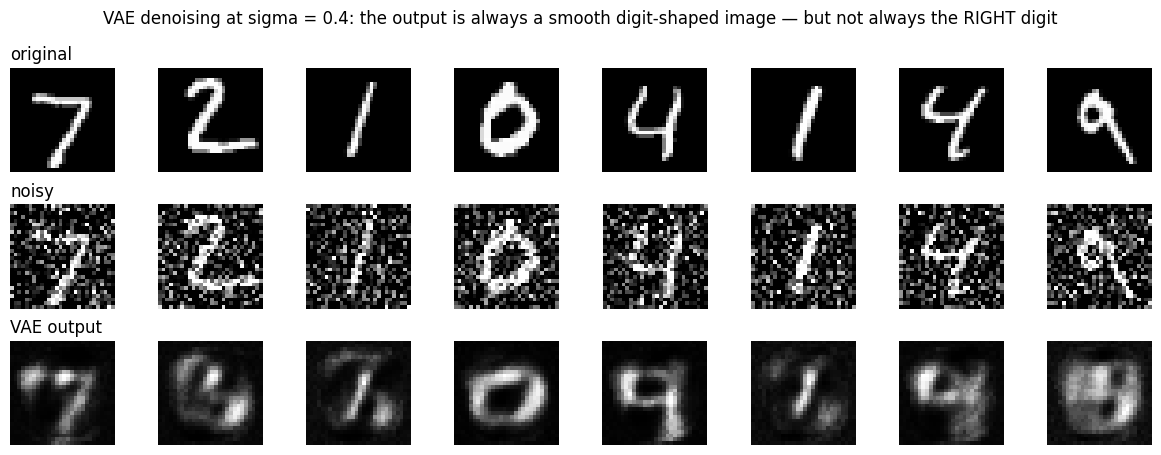

Compare the printed MSEs: the VAE output is closer to the original than
the noisy input — denoising achieved without ever training on noise.
Now compare the top and bottom rows image by image: several columns come back
as a clean digit of the WRONG identity. The MSE cannot see that; the next
cell sweeps the noise level and shows how far the disagreement goes.


In [1]:
# WHAT/WHY: train a VAE on clean MNIST, then use it as a DENOISER: encode a
# noise-corrupted digit, decode, and measure how much closer to the original
# the reconstruction is (MSE printed) than the noisy input was.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16

dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=128, shuffle=True)

class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        # Encoder: image → hidden features → two heads (mean, log-variance)
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        # Decoder: latent vector → image (Sigmoid keeps pixels in [0, 1])
        self.dec_fc = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, lv):
        # z = mu + sigma*eps: sampling that gradients can flow through
        return mu + (0.5 * lv).exp() * torch.randn_like(mu)
    def decode(self, z):
        return self.dec_fc(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(z=LATENT)
opt = optim.Adam(model.parameters(), lr=1e-3)

# ── Train on CLEAN digits only (5 epochs) ─────────────────────────────────
for epoch in range(5):
    for x, _ in loader:
        recon, mu, lv = model(x)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - 0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"Epoch {epoch+1}/5 — loss/image: {loss.item():.1f}")
model.eval()

# ── Corrupt unseen test digits with Gaussian pixel noise ──────────────────
test_ds = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=T.ToTensor())
clean = torch.stack([test_ds[i][0] for i in range(8)])
noisy = (clean + 0.4 * torch.randn_like(clean)).clamp(0, 1)

# ── Denoise: just encode + decode the noisy images ────────────────────────
with torch.no_grad():
    denoised, _, _ = model(noisy)

# ── Verify with numbers: is the reconstruction closer to the original? ────
mse_noisy    = F.mse_loss(noisy,    clean).item()
mse_denoised = F.mse_loss(denoised, clean).item()
print(f"\nMSE vs original — noisy input: {mse_noisy:.4f}   after VAE: {mse_denoised:.4f}")

fig, axes = plt.subplots(3, 8, figsize=(12, 4.6))
for i in range(8):
    axes[0, i].imshow(clean[i].squeeze(),    cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(noisy[i].squeeze(),    cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].squeeze(), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_title("original", loc='left'); axes[1, 0].set_title("noisy", loc='left')
axes[2, 0].set_title("VAE output", loc='left')
plt.suptitle("VAE denoising at sigma = 0.4: the output is always a smooth digit-shaped image — but not always the RIGHT digit")
plt.tight_layout(); plt.show()
print("Compare the printed MSEs: the VAE output is closer to the original than")
print("the noisy input — denoising achieved without ever training on noise.")
print("Now compare the top and bottom rows image by image: several columns come back")
print("as a clean digit of the WRONG identity. The MSE cannot see that; the next")
print("cell sweeps the noise level and shows how far the disagreement goes.")


## How Far Does the Trick Go?

One noise level is one data point. Below we sweep sigma from 0 (clean) to 1.0 (heavier noise
than the demo) on 300 unseen test digits and plot the error of the *input* against the error
of the *VAE's output*. The gap between the two curves is the denoiser's value — and the place
they cross is where it stops having any.

 sigma  MSE of noisy input   MSE after VAE   verdict
   0.0              0.0000          0.0263   HURTS
   0.1              0.0055          0.0301   HURTS
   0.2              0.0213          0.0407   HURTS
   0.3              0.0463          0.0518   HURTS
   0.4              0.0795          0.0630   helps
   0.6              0.1502          0.0751   helps
   0.8              0.2080          0.0816   helps
   1.0              0.2522          0.0854   helps


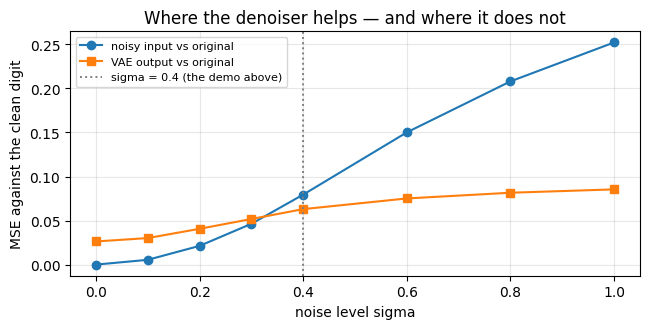

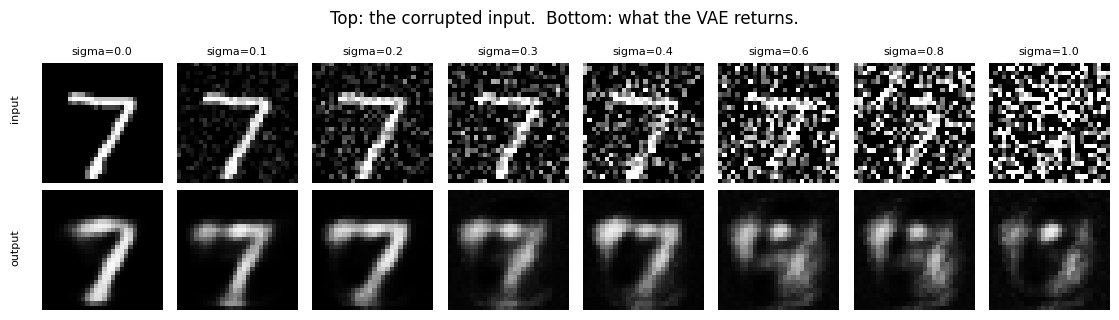

In [2]:
# WHAT/WHY: the denoising result above was measured at ONE noise level
# (sigma = 0.4). One number cannot say where the trick starts paying off or
# where it collapses, so we sweep sigma over 300 unseen test digits and plot
# both error curves on one axis — then show the same sweep as images.
sigmas     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
eval_clean = torch.stack([test_ds[i][0] for i in range(300)])
sweep_gen  = torch.Generator().manual_seed(7)   # own generator: global RNG untouched

mse_in, mse_out, strip_noisy, strip_out = [], [], [], []
with torch.no_grad():
    for s in sigmas:
        nz = (eval_clean + s * torch.randn(eval_clean.shape, generator=sweep_gen)).clamp(0, 1)
        out, _, _ = model(nz)
        mse_in.append(F.mse_loss(nz, eval_clean).item())
        mse_out.append(F.mse_loss(out, eval_clean).item())
        strip_noisy.append(nz[0, 0].numpy()); strip_out.append(out[0, 0].numpy())

# ── step table: at each noise level, did passing through the VAE help? ────
print(f"{'sigma':>6} {'MSE of noisy input':>19} {'MSE after VAE':>15}   verdict")
for s, a, b in zip(sigmas, mse_in, mse_out):
    print(f"{s:>6.1f} {a:>19.4f} {b:>15.4f}   {'helps' if b < a else 'HURTS'}")

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(sigmas, mse_in,  'o-', label="noisy input vs original")
ax.plot(sigmas, mse_out, 's-', label="VAE output vs original")
ax.axvline(0.4, color='gray', ls=':', lw=1.4, label="sigma = 0.4 (the demo above)")
ax.set_xlabel("noise level sigma"); ax.set_ylabel("MSE against the clean digit")
ax.set_title("Where the denoiser helps — and where it does not")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── the same sweep as a storyboard: one digit, rising corruption ──────────
fig, axes = plt.subplots(2, len(sigmas), figsize=(1.4 * len(sigmas), 3.3))
for j, s in enumerate(sigmas):
    axes[0, j].imshow(strip_noisy[j], cmap='gray', vmin=0, vmax=1); axes[0, j].axis('off')
    axes[1, j].imshow(strip_out[j],   cmap='gray', vmin=0, vmax=1); axes[1, j].axis('off')
    axes[0, j].set_title(f"sigma={s}", fontsize=8)
fig.text(0.005, 0.68, "input",  fontsize=8, rotation=90, va='center')
fig.text(0.005, 0.26, "output", fontsize=8, rotation=90, va='center')
plt.suptitle("Top: the corrupted input.  Bottom: what the VAE returns.")
plt.tight_layout(rect=[0.02, 0, 1, 1]); plt.show()


### 👁️ Read the figures — and note that they disagree

**The curves cross between sigma = 0.3 and sigma = 0.4.** Below the crossing the table prints
HURTS: pushing a lightly corrupted digit through the VAE adds more error than the noise it
removes. At sigma = 0 the input error is exactly 0.0000 and the output error is 0.0263 — that
number is the reconstruction blur, the error floor this model can never go below. The demo
above ran at sigma = 0.4 (dotted line), just past the crossing.

**Above the crossing the gap widens and the orange curve flattens.** At sigma = 1.0 the noisy
input scores 0.252 and the VAE output 0.085 — roughly a 3× improvement, and an output curve
so flat it looks like robustness to any amount of noise.

**Now look at the storyboard, which says something else.** Up to sigma = 0.4 the output is
still the 7 — blurry, thickened, but the right digit. From sigma = 0.6 on it is not a 7 any
more: it is a smooth, *wrong* shape, and by sigma = 1.0 it is a grey smear that is not a digit
at all. The MSE stayed nearly flat because the VAE's output is always a smooth, mostly-dark
image, and any smooth mostly-dark image stays a bounded distance from a mostly-dark original —
so the metric cannot see the identity failure your eye sees instantly. That is the concrete answer to Discuss question 1, and the reason every
denoising MSE in this notebook is printed next to its images.

## 💬 Discuss

1. MSE improved from **0.0798 (noisy input) to 0.0585 (VAE output)** — a 27% reduction — and the output is also visibly blurrier than the original. Is MSE the right score for "denoised"? What would you show a customer instead of, or alongside, that number?
2. The VAE was never trained on noise. Name one corruption this trick will handle well and one it will fail on — and say what property of the corruption decides which.
3. Face generation and style transfer appear here as recipes because CelebA training needs GPU-days. A client asks for face generation next week. What do you propose instead of training one, and what do you tell them you are giving up?


## Hands-On 2 — 🌍 Anomaly Detection (production pattern)

**Industry context:** assembly-line defect detection, payment fraud scoring, anomalous-scan flagging — all run this exact pattern: model the *normal* class, threshold the reconstruction error.


Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error — Normal (0): 0.0183  Anomaly (8): 0.0588
 threshold  detection rate   false-alarm rate
    0.0250           100%               19%
    0.0300           100%                7%
    0.0358            98%                7%  <- mean + 2*sd
    0.0450            92%                2%
    0.0500            74%                0%


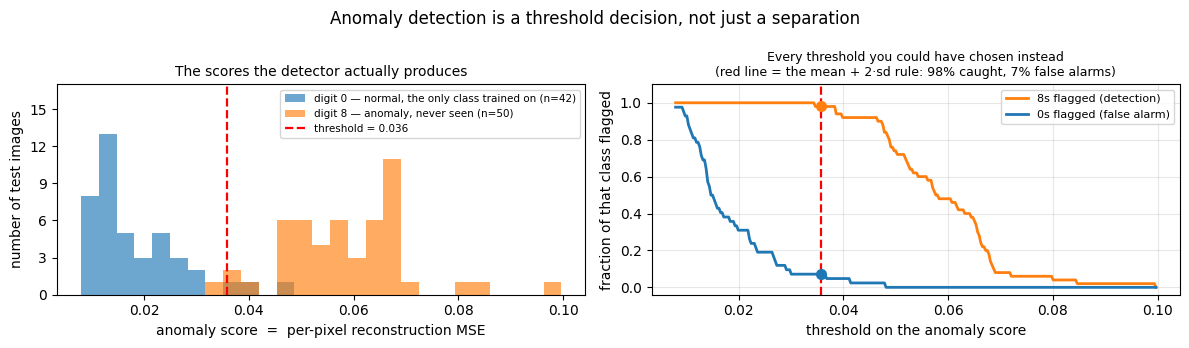

In [3]:
# WHAT/WHY: the anomaly-detection pattern from example 01, kept here as the
# second hands-on application: train on digit 0 only, then unseen digit 8
# reconstructs badly and crosses the error threshold. The figure adds the
# production part example 01 leaves out: what every other threshold costs.
torch.manual_seed(42)

# ── "Normal" training data: the first 2000 images of digit 0 only ─────────
idx_0 = [i for i, (x, y) in enumerate(dataset) if y == 0][:2000]
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

anomaly_model = VAE()
opt = optim.Adam(anomaly_model.parameters(), lr=1e-3)


# ── Train the VAE on normals only — it never sees an 8 ────────────────────
for epoch in range(15):
    total = 0
    for x, _ in normal_loader:
        recon, mu, lv = anomaly_model(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5 * kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")


# ── Score held-out digits: reconstruction error is the anomaly signal ─────
anomaly_model.eval()
samples_0 = torch.stack([test_ds[i][0] for i in range(500)  if test_ds[i][1] == 0][:50])
samples_8 = torch.stack([test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8][:50])

def recon_error(imgs):
    with torch.no_grad():
        recon, _, _ = anomaly_model(imgs)
        return F.mse_loss(recon, imgs, reduction='none').view(len(imgs), -1).mean(1)

err_0 = recon_error(samples_0).numpy()
err_8 = recon_error(samples_8).numpy()
print(f"\nReconstruction error — Normal (0): {err_0.mean():.4f}  Anomaly (8): {err_8.mean():.4f}")


# ── The production question is not "do they separate" but "where do you put
# the line". Left: the two score distributions with the 2-sigma operating
# point on them. Right: what every OTHER choice of line would have cost —
# detection rate and false-alarm rate swept across the whole score range.
thresh = err_0.mean() + 2 * err_0.std()          # the usual normal-only rule
lo, hi = min(err_0.min(), err_8.min()), max(err_0.max(), err_8.max())
grid   = np.linspace(lo, hi, 300)
det    = np.array([(err_8 > t).mean() for t in grid])   # anomalies flagged
fa     = np.array([(err_0 > t).mean() for t in grid])   # normals wrongly flagged

print(f"{'threshold':>10} {'detection rate':>15} {'false-alarm rate':>18}")
for t in [0.025, 0.030, thresh, 0.045, 0.050]:
    mark = "  <- mean + 2*sd" if abs(t - thresh) < 1e-9 else ""
    print(f"{t:>10.4f} {(err_8 > t).mean():>14.0%} {(err_0 > t).mean():>17.0%}{mark}")

fig, (axh, axt) = plt.subplots(1, 2, figsize=(12, 3.5))

bins = np.linspace(lo, hi, 28)
axh.hist(err_0, bins=bins, alpha=0.65, color='tab:blue',
         label=f"digit 0 — normal, the only class trained on (n={len(err_0)})")
axh.hist(err_8, bins=bins, alpha=0.65, color='tab:orange',
         label=f"digit 8 — anomaly, never seen (n={len(err_8)})")
axh.axvline(thresh, color='red', ls='--', lw=1.6, label=f"threshold = {thresh:.3f}")
axh.set_xlabel("anomaly score  =  per-pixel reconstruction MSE")
axh.set_ylabel("number of test images")
axh.set_title("The scores the detector actually produces", fontsize=10)
axh.set_ylim(0, 17)          # headroom so the legend never sits on a bar
axh.set_yticks(range(0, 18, 3))   # counts are integers
axh.legend(fontsize=7.5, loc='upper right')

axt.plot(grid, det, lw=2, color='tab:orange', label="8s flagged (detection)")
axt.plot(grid, fa,  lw=2, color='tab:blue',   label="0s flagged (false alarm)")
axt.axvline(thresh, color='red', ls='--', lw=1.6)
axt.plot([thresh], [(err_8 > thresh).mean()], 'o', color='tab:orange', ms=7, zorder=5)
axt.plot([thresh], [(err_0 > thresh).mean()], 'o', color='tab:blue',   ms=7, zorder=5)
axt.set_xlabel("threshold on the anomaly score")
axt.set_ylabel("fraction of that class flagged")
axt.set_ylim(-0.04, 1.10)
axt.set_title("Every threshold you could have chosen instead\n"
              f"(red line = the mean + 2·sd rule: {(err_8 > thresh).mean():.0%} caught, "
              f"{(err_0 > thresh).mean():.0%} false alarms)", fontsize=9)
axt.legend(fontsize=8, loc='upper right'); axt.grid(alpha=0.3)

plt.suptitle("Anomaly detection is a threshold decision, not just a separation")
plt.tight_layout(); plt.show()


### 👁️ Read the figures

**Left — the scores.** Blue is the normal class (digit 0), orange the anomaly class (digit 8)
this model never saw. The orange mass sits to the right of the blue mass: an unseen shape
reconstructs badly, and the reconstruction error is therefore usable as a score. The two
distributions **overlap** near the red line — they are separated, not disjoint.

**Right — the decision you still have to make.** This panel is the same 92 scores, read a
different way: for every possible threshold, what fraction of 8s would be flagged (orange) and
what fraction of 0s would be flagged by mistake (blue). Both curves fall as the threshold rises,
and they do not fall together — that gap between them is the detector's whole value. Read off
the trade: slide the line left and the orange curve climbs to 100%, but the blue curve climbs
with it; slide it right and false alarms vanish along with the catches.

The red line is the `mean + 2·sd of the normal class` rule, which is the only rule you can
actually apply in production, because in production you have normals and no labelled anomalies.
It is not the optimum of this picture — it is a defensible default whose cost this panel makes
visible. **In a real deployment the position of that line is a business decision** (what does a
missed defect cost versus an unnecessary inspection?), not a modelling one.

## ⚠️ Where this breaks

**The decoder can only draw things in its training distribution — that is the trick *and* the failure.** Feed it a valid input from outside that distribution and it will "clean" it into something wrong, confidently and without any signal that it has done so. A VAE trained on MNIST will happily turn a handwritten letter into a digit.

**MSE rewards blur.** A denoiser optimised on mean squared error will always prefer a smooth average to a sharp guess, so the metric and the visible quality disagree by construction. Every reported denoising MSE improvement should be read next to the images.

**Two jobs, one threshold.** The reconstruction error the denoiser is trying to *minimise* is the same error the anomaly detector uses as its *signal*. Tuning the model to denoise better makes it a worse anomaly detector, and vice versa. Decide which product you are building before you tune.

**Face generation is not "the same thing at a bigger scale".** CelebA-scale VAEs produce notoriously blurry faces; the sharp results people associate with generated faces come from StyleGAN or diffusion. Do not promise a client a VAE face generator on the strength of an MNIST demo.


## 🔭 State of the field (2026)

Reconstruction error is no longer how industrial visual anomaly detection is done. Current practice
compares **patch features from a frozen vision foundation model** against the few normal images you
have: AnomalyDINO does this with DINOv2, training-free, and rivals vision-language detectors in the
one- and few-shot setting (Damm et al., 2024, arXiv 2405.14529). 2026 work pushes into zero-shot —
adapting a foundation backbone with synthetically generated defects so it can flag anomalies in a
domain it was never trained on (Fučka et al., 2026, arXiv 2601.20524). The denoising half of this
notebook aged better: passing a corrupted image through a learned bottleneck is still exactly how
denoisers are framed.

**Why this lesson is still the right thing to learn.** "An anomaly is what the model cannot rebuild"
is the idea underneath all of that work, and a VAE is the cheapest place to see it end to end — train
on normal data only, score by reconstruction error, and pick a threshold from a real error
distribution rather than a rule of thumb. It is also the baseline those papers report against, it
needs no pretrained backbone, no GPU and no internet, and it is what the official plan examines.

## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- An & Cho (2015) — [Variational Autoencoder based Anomaly Detection](https://www.semanticscholar.org/paper/Variational-Autoencoder-based-Anomaly-Detection-An-Cho/061146b1d7938d7a8dae70e3531a00fceb3c78e8)
- Karras et al. (2019) — [StyleGAN](https://arxiv.org/abs/1812.04948) *(the production approach to face generation)*
- Pang et al. (2021) — [Deep Learning for Anomaly Detection: A Review](https://arxiv.org/abs/2007.02500) *(ACM Computing Surveys; where reconstruction-based detection fits)*
- Damm et al. (2024) — [AnomalyDINO: Boosting Patch-based Few-shot Anomaly Detection with DINOv2](https://arxiv.org/abs/2405.14529) *(training-free detection from frozen foundation-model features — the modern alternative to reconstruction error)*
- Fučka et al. (2026) — [AnomalyVFM: Transforming Vision Foundation Models into Zero-Shot Anomaly Detectors](https://arxiv.org/abs/2601.20524) *(zero-shot detection in domains the detector has never been trained on)*
- Shi et al. (2026) — [ScaleResfusion: Residual Rectified Flow based on Residual Vector Field](https://arxiv.org/abs/2607.25275) *(how the denoising half of this notebook is done in 2026: a pretrained rectified-flow generator adapted to real-world restoration, with the transport path starting from the degraded image rather than from pure noise)*

**Datasets to try with a GPU:** [CelebA](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html), [FFHQ](https://github.com/NVlabs/ffhq-dataset)


## 📝 Summary

In **02 — VAE Applications** you saw four applications of one architecture: face generation and style transfer as recipes (their full-scale training is beyond classroom hardware — the references show the way), and two applications **run and verified here**: denoising (the VAE output's MSE to the original beat the noisy input's — see printed numbers) and anomaly detection (the unseen class produced clearly higher reconstruction errors). Advanced variants — conditional VAEs and β-VAE — are next, in example 03.
